ГЕНЕРАТОР "ЖИЗНЕННОГО ЦИКЛА КЛИЕНТА"

с сгенерированным датасетом

учебная версия

1 вариант

End-to-end synthetic Customer Support Knowledge Graph + GraphRAG evaluation framework

Генерация:
клиенты
обращения
диалоги

NLP:
embeddings
semantic search
BERTopic

Graph:
knowledge graph
связи клиентов, тикетов, тем

GraphRAG:
retrieval через FAISS + граф

Export:
Neo4j-ready CSV

УСТАНОВКА ЗАВИСИМОСТЕЙ

In [3]:
!pip install -q pandas networkx matplotlib sentence-transformers bertopic faiss-cpu scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 67.5 MB/s eta 0:00:00


ИМПОРТ БИБЛИОТЕК

In [4]:
import random
import uuid
from datetime import datetime, timedelta
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

import faiss

КОНФИГУРАЦИЯ ДАННЫХ

In [5]:
NUM_CLIENTS = 50

PRODUCTS = [
    "Кредитная карта",
    "Дебетовая карта",
    "Потребительский кредит",
    "Инвестиционный счет",
    "Страхование"
]

EVENTS = [
    "introduction",
    "product_interest",
    "purchase",
    "support_question",
    "complaint",
    "followup",
    "repeat_purchase"
]

ШАБЛОНЫ ДИАЛОГОВ

In [6]:
CLIENT_TEMPLATES = {
    "complaint": [
        "У меня проблема с продуктом.",
        "Я недоволен обслуживанием.",
        "Хочу оставить жалобу."
    ],
    "support_question": [
        "Как пользоваться продуктом?",
        "Где посмотреть детали?",
        "Нужна помощь."
    ],
    "product_interest": [
        "Расскажите про продукт {product}.",
        "Какие условия?"
    ],
    "purchase": [
        "Хочу оформить {product}.",
        "Готов купить."
    ],
    "introduction": [
        "Здравствуйте, хочу узнать о продуктах.",
        "Какие есть услуги?"
    ],
    "followup": [
        "Есть новости?",
        "Проверяю статус."
    ],
    "repeat_purchase": [
        "Хочу ещё продукт.",
        "Есть дополнительные предложения?"
    ]
}

AGENT_TEMPLATES = {
    k: [
        "Понял, уточняю информацию.",
        "Сейчас помогу вам.",
        "Спасибо за обращение."
    ] for k in EVENTS
}

ГЕНЕРАЦИЯ КЛИЕНТА

In [7]:
def generate_client():
    return {
        "client_id": str(uuid.uuid4()),
        "product": random.choice(PRODUCTS)
    }

ГЕНЕРАЦИЯ ДИАЛОГА

In [8]:
def generate_dialog(event, product):
    msgs = []
    turns = random.randint(3, 5)

    msgs.append(("client", random.choice(CLIENT_TEMPLATES[event]).format(product=product)))

    for _ in range(turns):
        msgs.append(("agent", random.choice(AGENT_TEMPLATES[event])))
        msgs.append(("client", random.choice(CLIENT_TEMPLATES[event]).format(product=product)))

    return msgs

ГЕНЕРАЦИЯ ДАТАСЕТА

In [9]:
rows = []

for _ in range(NUM_CLIENTS):

    client = generate_client()

    start_date = datetime(2025, 1, 1)
    prev_ticket = None

    for i, event in enumerate(EVENTS, start=1):

        ticket_id = str(uuid.uuid4())
        start_date += timedelta(days=random.randint(5, 25))

        dialog = generate_dialog(event, client["product"])

        for j, (speaker, text) in enumerate(dialog):

            rows.append({
                "client_id": client["client_id"],
                "ticket_id": ticket_id,
                "previous_ticket_id": prev_ticket,
                "event_type": event,
                "event_order": i,
                "message_order": j,
                "speaker": speaker,
                "product": client["product"],
                "date": start_date,
                "text": text
            })

        prev_ticket = ticket_id

df = pd.DataFrame(rows)

df.head()

,client_id,ticket_id,previous_ticket_id,event_type,event_order,message_order,speaker,product,date,text
0,b02534e1-e959-4600-b62f-4a6d3a417228,151f9959-db7c-4de9-9c26-d681270e6900,None,introduction,1,0,client,Кредитная карта,2025-01-15,"Здравствуйте, хочу узнать о продуктах."
1,b02534e1-e959-4600-b62f-4a6d3a417228,151f9959-db7c-4de9-9c26-d681270e6900,None,introduction,1,1,agent,Кредитная карта,2025-01-15,Сейчас помогу вам.
2,b02534e1-e959-4600-b62f-4a6d3a417228,151f9959-db7c-4de9-9c26-d681270e6900,None,introduction,1,2,client,Кредитная карта,2025-01-15,"Здравствуйте, хочу узнать о продуктах."
3,b02534e1-e959-4600-b62f-4a6d3a417228,151f9959-db7c-4de9-9c26-d681270e6900,None,introduction,1,3,agent,Кредитная карта,2025-01-15,"Понял, уточняю информацию."
4,b02534e1-e959-4600-b62f-4a6d3a417228,151f9959-db7c-4de9-9c26-d681270e6900,None,introduction,1,4,client,Кредитная карта,2025-01-15,Какие есть услуги?


СОХРАНЕНИЕ

In [10]:
df.to_csv("dialogs.csv", index=False)

ЭМБЕДДИНГИ

In [11]:
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["text"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

FAISS индекс

In [12]:
dim = embeddings.shape[1]

index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings).astype("float32"))

СЕМАНТИЧЕСКИЙ ПОИСК

In [13]:
def search(query, k=5):
    q = model.encode([query])
    D, I = index.search(np.array(q).astype("float32"), k)
    return df.iloc[I[0]][["ticket_id", "text"]]

BERTopic
ТЕМЫ

In [14]:
topic_model = BERTopic(language="multilingual")
topics, probs = topic_model.fit_transform(texts)

df["topic"] = topics

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Knowledge Graph

In [15]:
G = nx.DiGraph()

In [16]:
for ticket_id, tdf in df.groupby("ticket_id"):

    row = tdf.iloc[0]

    client = row["client_id"]
    product = row["product"]
    topic = row["topic"]

    G.add_node(client, type="Client")
    G.add_node(ticket_id, type="Ticket")
    G.add_node(product, type="Product")
    G.add_node(str(topic), type="Topic")

    G.add_edge(client, ticket_id, rel="CREATED")
    G.add_edge(ticket_id, product, rel="ABOUT")
    G.add_edge(ticket_id, str(topic), rel="HAS_TOPIC")

    prev = row["previous_ticket_id"]

    if pd.notna(prev):
        G.add_edge(ticket_id, prev, rel="FOLLOWS")

    for _, msg in tdf.iterrows():
        G.add_node(msg.name, type="Message")
        G.add_edge(ticket_id, msg.name, rel="HAS_MESSAGE")

GraphRAG

In [17]:
def graph_rag(query):

    results = search(query, 3)

    context = []

    for idx in results.index:

        row = df.loc[idx]
        ticket = row["ticket_id"]

        context.append(row["text"])

        context.extend(list(G.neighbors(ticket)))

    return "\n".join(set(map(str, context)))

ТЕСТ GraphRAG

In [18]:
print(graph_rag("жалоба на продукт"))

У меня проблема с продуктом.
37
238
Страхование
12
663034fb-f15b-47a3-aefd-3fe152834dc4
13
41
237
42
241
36
39
40
34
235
35
236
239
e8709b8a-8911-4f21-a4bb-08dc1276a6ee
240
Кредитная карта
38


ВИЗУАЛИЗАЦИЯ ГРАФА

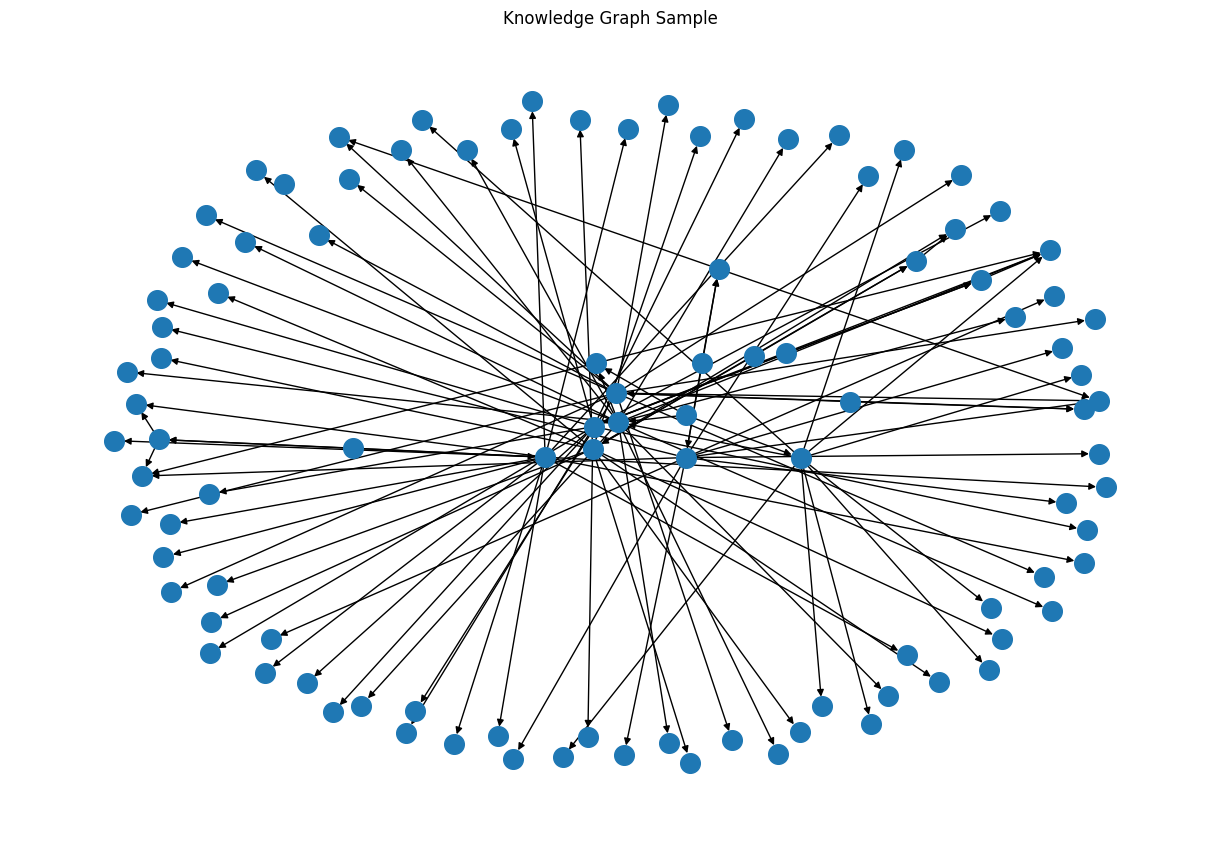

In [19]:
sub = list(G.nodes())[:100]

H = G.subgraph(sub)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42)

nx.draw(H, pos, node_size=200, with_labels=False)
plt.title("Knowledge Graph Sample")
plt.show()

Экспорт для Neo4j

In [20]:
nodes = [(n, G.nodes[n]["type"]) for n in G.nodes()]
edges = [(u, v, d["rel"]) for u, v, d in G.edges(data=True)]

pd.DataFrame(nodes, columns=["id", "type"]).to_csv("nodes.csv", index=False)
pd.DataFrame(edges, columns=["source", "target", "rel"]).to_csv("edges.csv", index=False)